# Forecaster explainability: feature importance, SHAP values and partial dependence plots

Machine learning explainability, also known as interpretability, refers to the ability to understand, interpret, and explain the decisions or predictions made by machine learning models in a human-understandable way. It aims to shed light on how a model arrives at a particular result or decision.

Due to the complex nature of many modern machine learning models, such as ensemble methods, they often function as black boxes, making it difficult to understand why a particular prediction was made. Explainability techniques aim to demystify these models, providing insight into their inner workings and helping to build trust, improve transparency, and meet regulatory requirements in various domains. Enhancing model explainability not only aids in understanding model behavior but also helps detect biases, improve model performance, and enables stakeholders to make more informed decisions based on machine learning insights.

Skforecast is compatible with some of the most widely used interpretability methods: model-specific feature importances, SHAP values, permutation importance and partial dependence plots.

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

To learn more about explainability, visit: <a href="https://cienciadedatos.net/documentos/py57-interpretable-forecasting-models.html">Interpretable forecasting models</a>

</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.plot import set_dark_theme

In [2]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


The data is recorded every 30 minutes. Since the goal is to forecast the daily demand, the series is aggregated to a daily frequency: the demand is summed and the temperature is averaged. The half-hourly records start at 13:00 on 2011-12-31 and end at 12:30 on 2014-12-31, so the first and last days of the aggregated series are incomplete. Their totals are not comparable with the rest of the days, so they are removed. Only `Demand` and `Temperature` are kept, so the `Holiday` column is not used by the model.

The last 10 days (from 2014-12-21 to 2014-12-30) are kept as the test set, and the rest of the series is used to train the model.

In [3]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

# Remove the first and last days, which are incomplete
data = data.loc['2012-01-01':'2014-12-30']
data.head(3)

,Demand,Temperature
Time,,
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708


In [4]:
# Split train-test
# ==============================================================================
data_train = data.loc[:'2014-12-20']
data_test  = data.loc['2014-12-21':]

## Forecasting model

A [`ForecasterRecursive`](https://skforecast.org/latest/api/forecasterrecursive) is created to predict the energy demand using a LightGBM regressor (`LGBMRegressor`), the past 7 values (last week) and the temperature as an exogenous variable.

In [5]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Calendar features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-12-20 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-10-01 16:32:08 
Last fit date: 2026-10-01 16:32:15 
Skforecast version: 0.25.0 
Python version: 3.13.14 
Forecaster id: None

## Model-specific feature importances

Feature importance is a technique used in machine learning to determine the relevance or importance of each feature (or variable) in a model's prediction. In other words, it measures how much each feature contributes to the model's output.

Feature importance can be used for several purposes, such as identifying the most relevant features for a given prediction, understanding the behavior of a model, and selecting the best set of features for a given task. It can also help to identify potential biases or errors in the data used to train the model. It is important to note that feature importance is not a definitive measure of causality. Just because a feature is identified as important does not necessarily mean that it causes the outcome. Other factors, such as confounding variables, may also be at play.

The method used to calculate feature importance may vary depending on the type of machine learning model being used. Different machine learning models may have different assumptions and characteristics that affect the calculation of feature importance. For example, tree-based models such as Random Forest and Gradient Boosting typically measure the importance of a feature by the total reduction of impurity (or loss) achieved by the splits that use it, or simply by the number of times it is used in a split. 

Linear regression models typically use coefficients or standardized coefficients to determine the importance of a feature. The magnitude of the coefficient reflects the strength and direction of the relationship between the feature and the target variable.

The importance of the predictors included in a forecaster can be obtained using the method [`get_feature_importances()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.get_feature_importances). This method accesses the `coef_` or `feature_importances_` attribute of the internal estimator.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

The <a href="https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.get_feature_importances"><code>get_feature_importances()</code></a> method only returns values if the forecaster's estimator has either the <code>coef_</code> or the <code>feature_importances_</code> attribute, which are the names used by scikit-learn and by the libraries that follow its API. If your estimator does not follow this naming convention, please consider opening an <a href="https://github.com/skforecast/skforecast/issues">issue on GitHub</a> and we will strive to include it in future updates.

</div>

In [6]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,567
0,lag_1,464
6,lag_7,391
1,lag_2,358
2,lag_3,346
4,lag_5,299
3,lag_4,291
5,lag_6,284


The values returned for `LGBMRegressor` are integers because, by default (`importance_type='split'`), LightGBM counts **how many times each feature is used to split a node** across all the trees. According to this criterion, `Temperature` (567 splits) and `lag_1` (464) are the most used predictors, followed by `lag_7` (391), the demand of the same day of the previous week. The number of splits does not measure how much each feature reduces the error: a feature can be used in many splits that barely improve the model. To obtain the total reduction of the loss instead, create the estimator with `LGBMRegressor(importance_type='gain')`.

To properly retrieve the feature importances in [`ForecasterDirect`](https://skforecast.org/latest/api/forecasterdirect) and [`ForecasterDirectMultiVariate`](https://skforecast.org/latest/api/forecasterdirectmultivariate), it is essential to specify the model from which the feature importances are to be extracted (argument `step`, for example `forecaster.get_feature_importances(step=1)`). This is because [Direct Strategy Forecasters](https://skforecast.org/latest/user_guides/direct-multi-step-forecasting) fit one model per step, and each model may have different important features. Therefore, the user must explicitly specify the step, so the importances returned correspond to the model trained for that step.

## SHAP explanations for skforecast models

**SHAP (SHapley Additive exPlanations)** values are a widely adopted method for explaining machine learning models. They provide both visual and quantitative insights into how features and their values impact the model. SHAP values serve two primary purposes:

+ **Global Interpretability**: SHAP values show how each feature influences the model's predictions across a dataset. By averaging the absolute SHAP values of each feature, one can rank features by their overall importance and gain insight into the model's decision-making process.

+ **Local Interpretability**: SHAP values also explain individual predictions by indicating how much each feature contributed to a specific output. This enables a breakdown of single predictions to understand the role each feature played in the outcome.

SHAP value explanations can be generated for skforecast models using two essential components:

+ The internal estimator of the forecaster, accessible via `forecaster.estimator`.

+ The internal matrices used for fitting, backtesting, and predicting with the forecaster. These matrices are accessible through the methods [`create_train_X_y()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_train_X_y) and [`create_predict_X()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_predict_X), and by setting the argument `return_predictors = True` in the [`backtesting_forecaster()`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) function.

By leveraging these elements, users can produce clear and interpretable explanations for their forecasting models. These explanations can be used to assess model reliability, identify the most influential features, and better understand the relationships between input variables and the target variable.

These explanations describe how the model uses the features, not causal relationships in the data. In addition, lags are strongly correlated with each other, so the model can spread the same information across several of them, and the contribution of an individual lag should not be interpreted in isolation (see the interpretation of `lag_2` below).

### SHAP feature importance in the overall model

Each observation receives one SHAP value per feature: its sign indicates whether the feature pushed that prediction up or down, and its absolute value indicates how strongly. Averaging the **absolute** SHAP values across the data set used to train the model gives an estimate of the overall importance of each feature (averaging the signed values would make positive and negative contributions cancel out). The direction of the effect is analyzed observation by observation, for example with the summary plot shown below.

First, the training matrices used to fit the model are created with the method [`create_train_X_y()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_train_X_y).

In [7]:
# Training matrices used by the forecaster to fit the internal estimator
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))  # Features
display(y_train.head(3))  # Target

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458
2012-01-10,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,16.042708


Time
2012-01-08    200061.614738
2012-01-09    216201.836844
2012-01-10    217176.907910
Freq: D, Name: y, dtype: float64

Then, the SHAP values are calculated using the [`shap`](https://shap.readthedocs.io/en/latest/) library. A `TreeExplainer` is created for the tree-based internal estimator. For other estimators, use `shap.LinearExplainer(estimator, X_train)` for linear models, or the model-agnostic `shap.Explainer(estimator.predict, X_background)`, which works with any estimator but is slower (see the [SHAP documentation](https://shap.readthedocs.io/en/latest/api.html#explainers)). Calling the explainer on a matrix of predictors returns an `Explanation` object that stores the SHAP values (`.values`), the base value of each observation (`.base_values`) and the values of the predictors (`.data`). All the plotting functions in `shap.plots` accept this object directly.

If the data set is large, it is recommended to use only a random sample. Here, half of the training observations are selected with `DataFrame.sample()`.

In [8]:
# Create SHAP explainer
# ==============================================================================
explainer = shap.TreeExplainer(forecaster.estimator)

# Sample 50% of the data to speed up the calculation
X_train_sample = X_train.sample(frac=0.5, random_state=785412)
shap_values = explainer(X_train_sample)

Once the SHAP values are calculated, several plots can be generated to visualize the results.

#### SHAP Summary Plot

The SHAP summary plot (also called beeswarm plot) displays the contribution of each feature to the model's output across multiple data points. It shows how much each feature pushes the prediction away from a base value (the average prediction of the model). By examining it, one can see which features have the most significant impact on predictions, whether they increase or decrease the outcome, and how different feature values contribute to specific predictions.

How to read it:

+ Each dot is one observation of the sample.

+ The horizontal position is the SHAP value: dots on the right increased the prediction, dots on the left decreased it.

+ The color is the value of the feature: red for high values, blue for low values.

+ Features are sorted from top to bottom by their mean absolute SHAP value.

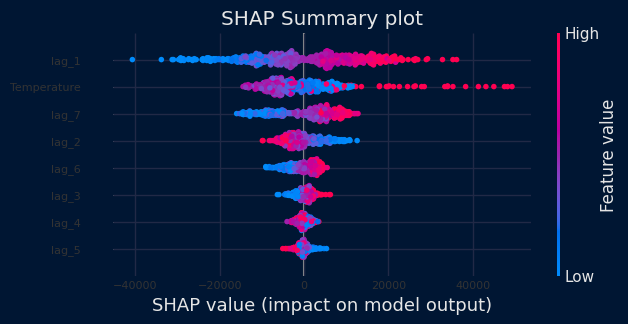

In [9]:
# SHAP summary plot (top 10)
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 3))
shap.plots.beeswarm(shap_values, max_display=10, ax=ax, plot_size=None, show=False)
ax.set_title("SHAP Summary plot")
ax.tick_params(labelsize=8)
plt.show()

For `lag_1`, red dots (high demand on the previous day) are located on the right and blue dots on the left: the higher the demand of the previous day, the higher the prediction. `lag_7` shows a similar, weaker pattern. `lag_2` shows the opposite pattern: high values decrease the prediction. This does not mean that a high demand two days ago lowers today's demand; since `lag_1` and `lag_2` are strongly correlated (correlation of about 0.68), once `lag_1` is known, the model uses `lag_2` to capture whether demand has recently risen or fallen. For `Temperature`, both some red dots (hot days) and some blue dots (cold days) have positive SHAP values, which suggests a non-linear effect. The dependence plot below analyzes it in more detail.

The bar plot summarizes the previous one by showing the mean absolute SHAP value of each feature, that is, the average size of its contribution to the predictions, regardless of its direction.

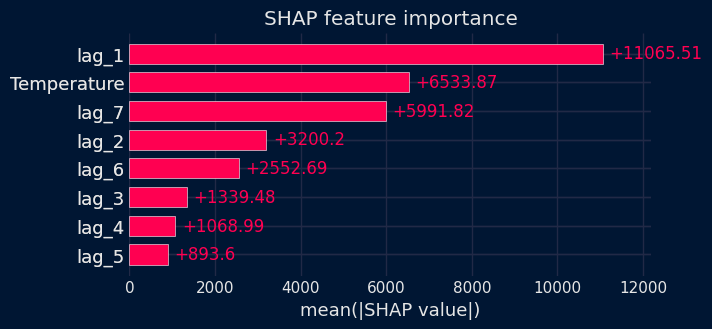

In [10]:
# SHAP feature importance (bar plot)
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 3))
shap.plots.bar(shap_values, ax=ax, show=False)
ax.set_title("SHAP feature importance")
plt.show()

According to the mean absolute SHAP values, `lag_1` is the most influential feature (about 11,066 units), followed by `Temperature` (about 6,534) and `lag_7` (about 5,992). This ranking differs from the split-based importance shown earlier, where `Temperature` came first: the split count measures how often a feature is used by the trees, while SHAP values measure how much it changes the predictions.

#### SHAP Dependence Plots

SHAP dependence plots show how the value of a single feature affects the predictions of the model across its whole range. Each dot is one observation: the horizontal axis is the value of the feature and the vertical axis is its SHAP value. The function `shap.plots.scatter` creates this plot. When the argument `color` receives the whole `Explanation` object, the dots are colored by the feature that has the strongest estimated interaction with the analyzed one, which helps to reveal whether the effect of the feature depends on another variable.

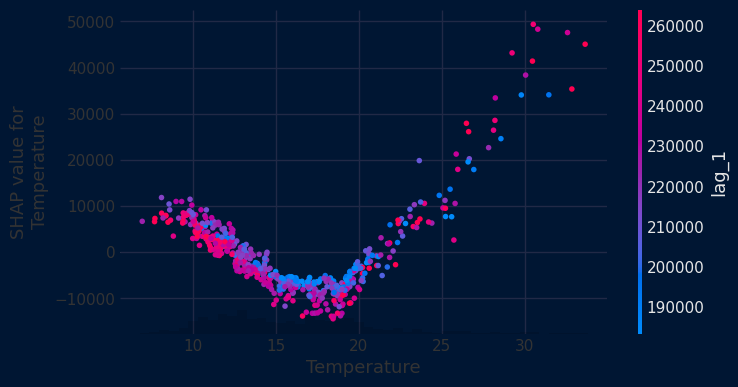

In [11]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.plots.scatter(shap_values[:, "Temperature"], color=shap_values, ax=ax)

The relationship between `Temperature` and its SHAP values has a U shape. Mild temperatures, roughly between 13 and 21 degrees Celsius, decrease the predicted demand (about -7,900 units on average between 15 and 18 degrees). Cold days, below 12 degrees, increase it (about +4,800 units), and hot days increase it much more: about +13,800 units between 24 and 27 degrees and more than +30,000 units above 27 degrees. This pattern reflects the use of electricity for heating in winter and, even more strongly, for air conditioning in summer. The points are colored by `lag_1`, the feature selected automatically as the one with the strongest interaction with `Temperature`. The coloring reveals a moderate interaction: for the same temperature, days that follow a high-demand day (red) receive a smaller contribution from `Temperature` than days that follow a low-demand day (blue). For example, between 15 and 20 degrees, the average SHAP value is about -9,950 when `lag_1` is above its median and about -6,855 when it is below. Since temperature persists from one day to the next, part of its effect is already reflected in the demand of the previous day.

### SHAP Explanations for Individual Predictions

SHAP values not only allow for interpreting the general behavior of the model (Global Interpretability) but also serve as a powerful tool for analyzing individual predictions (Local Interpretability). This is especially useful when trying to understand why a model made a specific prediction for a given instance.

To carry out this analysis, it is necessary to access the values of the predictors (lags, window features and exogenous variables) at the time of the prediction. This can be achieved by using the [`create_predict_X`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_predict_X) method or by enabling the `return_predictors = True` argument in the [`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) function.

#### SHAP values of predict output

Suppose the forecaster is employed to predict the next 10 values of the series, and a specific prediction corresponding to the date '2014-12-21' requires explanation.

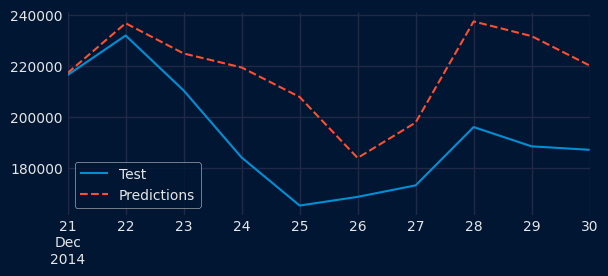

In [12]:
# Forecasting next 10 days
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])

fig, ax = plt.subplots(figsize=(6, 2.5))
data_test['Demand'].plot(ax=ax, label='Test')
predictions.plot(ax=ax, label='Predictions', linestyle='--')
ax.set_xlabel(None)
ax.legend();

The forecast is accurate for the first two days (21 and 22 December), but from 2014-12-23 onward it overestimates the demand in every step, with errors of up to about 43,000 units (2014-12-25 and 2014-12-29). These days belong to the Christmas period, when demand is usually lower: in 2012 and 2013, the average demand between 24 and 31 December was 16-18% lower than in the first 20 days of the month. The model has no feature that identifies this period (the `Holiday` column only flags public holidays, such as 25 and 26 December, and it was not included in the model). In addition, since the forecaster is recursive, each overestimated prediction is used as a lag in the following steps, so the error propagates along the horizon. A feature that marks the holiday season (for example, the days between Christmas and New Year) could help the model to capture this drop in demand.

SHAP values can help to understand why the model made a given prediction.

The method [`create_predict_X()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_predict_X) is used to create the input matrix used internally by the forecaster's [`predict()`](https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.predict) method. This matrix is then used to generate SHAP values for the forecasted values.

In [13]:
# Create input matrix used to forecast the next 10 steps
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict.head(3)

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-21,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,206976.350998,24.031250
2014-12-22,217278.445215,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,236763.589405,217278.445215,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167


<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

If transformations (<code>transformer_y</code>) or differentiation are included in the Forecaster, the output matrix is in the transformed scale, and so are the SHAP values computed from it: they explain the output of the internal estimator, not the final prediction. The values of the predictors can be converted back to the original scale, but the SHAP values cannot, in general, be converted by applying the same inverse transformation (with differentiation, for example, they explain the change between consecutive values, not the level of the series). For more information, visit: <a href="https://skforecast.org/latest/user_guides/training-and-prediction-matrices">Extract training and prediction matrices</a>.

</div>

In [14]:
# SHAP values for the predictions
# ==============================================================================
shap_values_predict = explainer(X_predict)

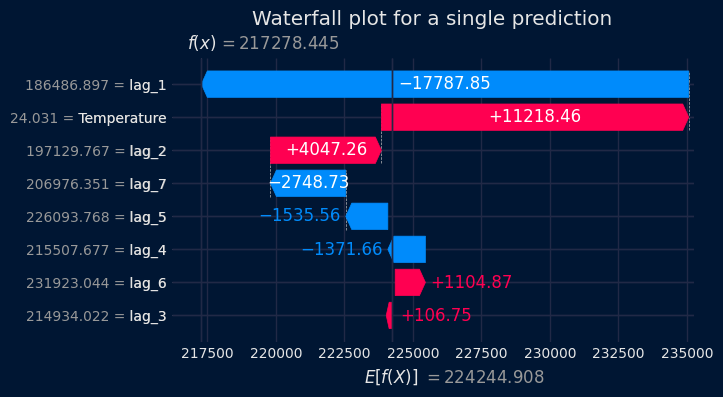

In [15]:
# Waterfall plot for a single prediction
# ==============================================================================
predicted_date = '2014-12-21'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)

shap.plots.waterfall(shap_values_predict[iloc_predicted_date], show=False)

fig = plt.gcf()
fig.set_size_inches(6, 3.5)
fig.axes[0].tick_params(labelsize=10)
fig.axes[0].set_title("Waterfall plot for a single prediction")
plt.show()

The waterfall plot starts from the expected value of the model, $E[f(X)] = 224{,}244.908$, which is the average prediction over the training data, and shows how each feature pushes the prediction for 2014-12-21 higher (red) or lower (blue) until the final value, $f(x) = 217{,}278.445$, is reached. Since 2014-12-21 is the first step of the forecast horizon, all the lags are observed values.

+ `lag_1` had the largest impact, reducing the prediction by about 17,788 units. It is the demand of Saturday 2014-12-20 (186,487), the lowest of the previous week and well below the average of the training data (about 224,000).

+ `Temperature` (24.03 degrees Celsius) had the largest positive impact, adding about 11,218 units. As shown in the dependence plot, warm days increase the demand because of the use of air conditioning.

+ `lag_2` (197,130) added about 4,047 units. As seen in the summary plot, the model uses `lag_2` in the opposite direction to `lag_1`, so a low value increases the prediction.

+ `lag_7`, the demand of the previous Sunday (206,976), is also below average and reduced the prediction by about 2,749 units.

The remaining lags have smaller contributions. Overall, the low demand of the weekend pushes the prediction below the average, and the warm temperature partially offsets this effect. The observed demand was 216,484, only about 800 units below the prediction.

SHAP values explain what the model did, not whether it was right. The same analysis can be applied to the overestimated predictions of the Christmas period, keeping in mind that, from the second step onward, the lags are values predicted by the model, not observed values.

The same information can be displayed with the `shap.plots.force` function. The force plot is interactive, so `shap.initjs()` must be called first to load the JavaScript code needed to render it in the notebook.

In [16]:
# Force plot for a single prediction
# ==============================================================================
shap.initjs()
shap.plots.force(shap_values_predict[iloc_predicted_date])

The force plot can also display several predictions at once. Each individual force plot is rotated 90 degrees and placed next to the others, so the horizontal axis represents the predictions and the vertical axis the output of the model. The plot is interactive: hovering over it shows the contribution of each feature. The drop-down menu of the vertical axis selects what is displayed (the output of the model or the effect of a single feature), and the drop-down menu of the horizontal axis selects how the predictions are ordered (original order, similarity, output value or the value of a feature).

Interactive plots require JavaScript, so they may not be displayed in static viewers such as GitHub.

In [17]:
# Force plot for the 10 predictions
# ==============================================================================
shap.plots.force(shap_values_predict)

In [`ForecasterDirect`](https://skforecast.org/latest/api/forecasterdirect), each step has its own estimator, `forecaster.estimators_[step]`. Row *i* of the matrix returned by `create_predict_X()` contains the predictors of step *i*, so it must be explained with an explainer built on the estimator of that step, for example `shap.TreeExplainer(forecaster.estimators_[2])` for the second row. The training matrix of a given step is obtained with [`filter_train_X_y_for_step(step, X_train, y_train, remove_suffix=True)`](https://skforecast.org/latest/api/forecasterdirect#skforecast.direct._forecaster_direct.ForecasterDirect.filter_train_X_y_for_step).

#### SHAP values of backtesting_forecaster() output

The analysis of individual predictions using SHAP values can also be applied to predictions made in a backtesting process. For that, the `return_predictors=True` argument must be set in the [`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) function. This will return a DataFrame with the predicted value ('pred'), the partition it belongs to ('fold'), and the value of the predictors (lags, window features and exogenous variables) used to make each prediction.

In this scenario, a backtesting process is employed to train the model using data up to '2014-12-01'. The model then generates predictions in folds of 24 steps (days). Since the backtesting period has 29 days (from 2014-12-02 to 2014-12-30), there are two folds: the first one with 24 predictions and the second one with the remaining 5. SHAP values are subsequently computed for the forecast corresponding to the date '2014-12-16', the 15th step of the first fold. Unlike the prediction explained in the previous section, the lags used to make this prediction are values predicted by the model in the previous steps of the fold, not observed values.

The SHAP explainer must be built on the same model that generated the backtesting predictions. [`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) works on a copy of the forecaster, which it trains with the first `initial_train_size` observations defined in the [`TimeSeriesFold`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._split.TimeSeriesFold) (with `refit=False`, it is never retrained). The forecaster used so far in this guide was trained with data up to '2014-12-20', so it has already seen part of the backtesting period and is not the model that produced these predictions. For this reason, a forecaster with the same configuration is trained with the same data used in the backtesting, and a new explainer is created from it.

In [18]:
# Backtesting returning the predictors
# ==============================================================================
end_backtest_train = '2014-12-01'
cv = TimeSeriesFold(steps=24, initial_train_size=len(data.loc[:end_backtest_train]))
_, backtest_predictions = backtesting_forecaster(
                     forecaster        = forecaster,
                     y                 = data['Demand'],
                     exog              = data['Temperature'],
                     cv                = cv,
                     metric            = 'mean_absolute_error',
                     return_predictors = True,
                 )
backtest_predictions.head(3)

  0%|          | 0/2 [00:00<?, ?it/s]

,fold,pred,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-02,0,232907.181373,237812.592388,234970.336660,189653.758108,202017.012448,214602.854760,218321.456402,214318.765210,19.833333
2014-12-03,0,230461.124839,232907.181373,237812.592388,234970.336660,189653.758108,202017.012448,214602.854760,218321.456402,19.616667
2014-12-04,0,232480.855309,230461.124839,232907.181373,237812.592388,234970.336660,189653.758108,202017.012448,214602.854760,21.702083


In [19]:
# Forecaster and explainer equivalent to the model used in the backtesting
# ==============================================================================
forecaster_backtest = ForecasterRecursive(
                          estimator = LGBMRegressor(random_state=123, verbose=-1),
                          lags      = 7
                      )
forecaster_backtest.fit(
    y    = data.loc[:end_backtest_train, 'Demand'],
    exog = data.loc[:end_backtest_train, 'Temperature']
)
explainer_backtest = shap.TreeExplainer(forecaster_backtest.estimator)

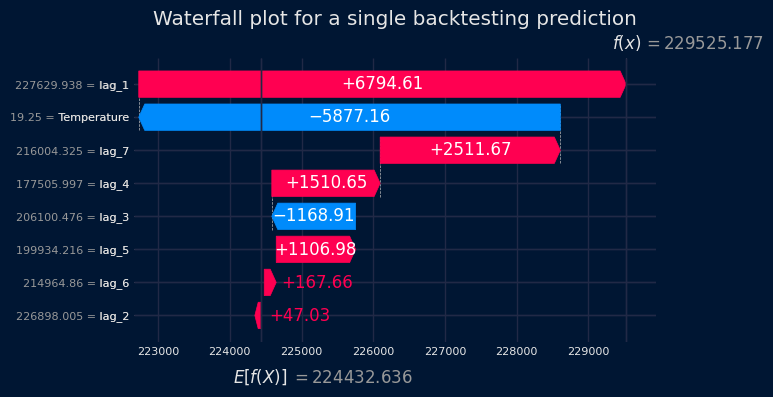

In [20]:
# Waterfall for a single prediction generated during backtesting
# ==============================================================================
# Select the predictors, in the same order as in the training matrix
X_backtest = backtest_predictions[forecaster_backtest.X_train_features_names_out_]
iloc_backtest_date = X_backtest.index.get_loc('2014-12-16')
shap_values_backtest = explainer_backtest(X_backtest)
shap.plots.waterfall(shap_values_backtest[iloc_backtest_date], show=False)

fig = plt.gcf()
fig.set_size_inches(6, 3.5)
fig.axes[0].tick_params(labelsize=8)
fig.axes[0].set_title("Waterfall plot for a single backtesting prediction")
plt.show()

The model used in the backtesting has a slightly different expected value, $E[f(X)] \approx 224{,}433$, because it was trained with different data. For 2014-12-16 it predicted $f(x) \approx 229{,}525$ (the observed demand was 226,094):

+ `lag_1` had the largest positive impact, adding about 6,795 units, followed by `lag_7` (about 2,512 units).

+ `Temperature` (19.25 degrees Celsius) had the largest negative impact, reducing the prediction by about 5,877 units. Mild temperatures reduce the need for heating and cooling, which is consistent with the dependence plot shown above.

Although all the lags used to make this prediction are values predicted by the model, the prediction is close to the observed value (an error of about 3,400 units): mid-December is not affected by the drop in demand of the holiday season.

## Permutation feature importance

Permutation feature importance is a model inspection technique that measures the contribution of each feature to the statistical performance of a fitted model on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model's score. By breaking the relationship between the feature and the target variable, it is possible to determine how much the model relies on that particular feature.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9999;&#65039; Note</b>
</p>

Two aspects should be considered when interpreting permutation importance in forecasting models:

<ul>
<li>In this example, the importance is computed on the training data, so it measures how much the model relies on each feature to reproduce the data it has learned from, not how much each feature helps to forecast new data. To assess the latter, it can be computed on data not used for training, for example the predictors returned by the backtesting with <code>return_predictors=True</code> together with the observed values.</li>
<li>Lags are usually strongly correlated with each other. When one of them is shuffled, the model can partly recover its information from the neighboring lags, so the importance of correlated features tends to be underestimated and shared among them.</li>
</ul>

</div>

In [21]:
# Permutation importances
# ==============================================================================
# X_train and y_train are the training matrices created in the SHAP section
perm_importance = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': perm_importance.importances_mean,
                  'std_importance': perm_importance.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.554377,0.036739
7,Temperature,0.463006,0.024375
6,lag_7,0.191631,0.009062
1,lag_2,0.113390,0.009857
5,lag_6,0.070953,0.003126
2,lag_3,0.033171,0.003162
3,lag_4,0.026360,0.001965
4,lag_5,0.024196,0.002198


Permutation importance ranks `lag_1` first (0.554), closely followed by `Temperature` (0.463) and, at a distance, by `lag_7` (0.192), whereas the split-based importance ranked `Temperature` first. The two methods answer different questions: the split count reflects how often the model uses a feature, while permutation importance measures how much the score of the model (the coefficient of determination, $R^2$, for regressors) drops when the information of a feature is destroyed. Both methods agree that `lag_1`, `Temperature` and `lag_7` are the most relevant predictors, and the ranking of the permutation importance is the same as the one obtained with the mean absolute SHAP values.

## Partial dependence plots

Partial dependence plots (PDPs) are a useful tool for understanding the relationship between a feature and the target outcome in a machine learning model. In scikit-learn, partial dependence plots are created with the [`PartialDependenceDisplay.from_estimator`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html#sklearn.inspection.PartialDependenceDisplay.from_estimator) method. This function visualizes the effect of one or two features on the predicted outcome, while marginalizing the effect of all other features.

The resulting plots show how changes in the selected feature(s) affect the predicted outcome, averaging the predictions over the observed values of the other features. Remember that these plots should be interpreted in the context of your model and data. They provide insight into the relationship between specific features and the model's predictions.

With `kind='both'`, the average partial dependence curve is drawn together with the individual conditional expectation (ICE) curves, one per observation, which reveal whether the effect of the feature is homogeneous across observations. To keep the plot readable, only a random subsample of 150 ICE curves is drawn (`subsample=150`).

Partial dependence plots vary the feature of interest while keeping the observed values of the other features, as if they were independent. This assumption does not hold for lags, which are strongly correlated with each other: when `lag_1` takes a very high value, the other lags keep their original values, producing combinations that never occur in the data. The curve of `lag_1` should therefore be interpreted with caution.

A more detailed description of partial dependence plots can be found in <a href="https://scikit-learn.org/stable/modules/partial_dependence.html#partial-dependence-and-individual-conditional-expectation-plots">scikit-learn's user guide</a>.

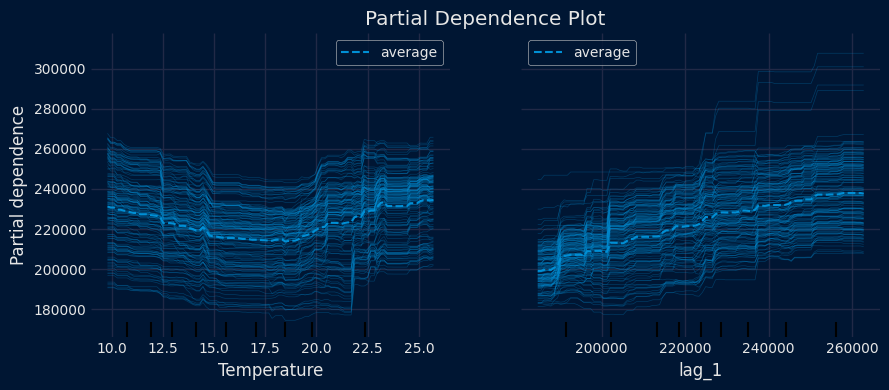

In [22]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator    = forecaster.estimator,
    X            = X_train,
    features     = ["Temperature", "lag_1"],
    kind         = 'both',
    subsample    = 150,
    random_state = 123,
    ax           = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

In the `Temperature` panel, the average curve has a U shape: the predicted demand is lowest (about 213,800) for temperatures around 18-19 degrees Celsius, and it grows for colder days (about 231,000 at 10 degrees) and for hotter days (about 234,500 at 26 degrees). This is the same heating and cooling effect found with the SHAP dependence plot. The curve covers the range between the 5th and 95th percentiles of the feature (from 9.8 to 25.7 degrees), which is the default grid used by scikit-learn. For this reason, the strongest effect found with SHAP values, on the hottest days (there are 38 days above 27 degrees in the training data), is not shown in the plot.

In the `lag_1` panel, the predicted demand increases with the demand of the previous day, from about 199,000 to about 237,700, and flattens for the highest values (above approximately 255,000). The curve is a step function because tree-based models produce piecewise constant predictions, and only 10% of the training values of `lag_1` are above 256,000 (the tick marks at the bottom of the plot show the deciles of the feature), so the trees have few splits in that region. In addition, tree-based models cannot extrapolate: for values of `lag_1` beyond the largest one seen during training, the prediction would remain constant.

## Summary

Each method answers a different question, so it is good practice to combine several of them:

| Method | What it measures | Scope | Main caveats |
|:-------|:-----------------|:------|:-------------|
| Model-specific importance (`get_feature_importances()`) | How the estimator uses each feature (number of splits, loss reduction or coefficients) | Global | Depends on the estimator and on the importance type; the split count does not measure the size of the effect |
| SHAP values | Contribution of each feature to each individual prediction, relative to the average prediction | Global and local | Explains the model, not reality; values are in the scale of the estimator output (transformed scale if `transformer_y` or differentiation are used) |
| Permutation importance | Drop of the model score when the information of a feature is destroyed | Global | Correlated features (such as lags) share and underestimate their importance; results depend on the data used (train or test) |
| Partial dependence plots (and ICE) | Average (and individual) change of the prediction when a feature varies | Global (and local with ICE) | Assumes independence between features, so combinations that never occur in the data are evaluated when features are correlated |

All of them explain the behavior of the model. None of them proves a causal relationship between the features and the target variable.